In [61]:
import numpy as np 
import pandas as pd 
import tensorflow.keras
import keras
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings

warnings.filterwarnings('ignore')

In [62]:
import tensorflow as tf
print(tf.__version__)
print(tf.keras.__version__)

2.20.0
3.13.2


In [63]:
(X_train,y_train), (X_test,y_test) = keras.datasets.fashion_mnist.load_data()

In [64]:
X_train.shape,y_train.shape

((60000, 28, 28), (60000,))

In [65]:
X_test.shape, y_test.shape

((10000, 28, 28), (10000,))

In [66]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

In [67]:
y_train[0]

np.uint8(9)

In [68]:
class_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

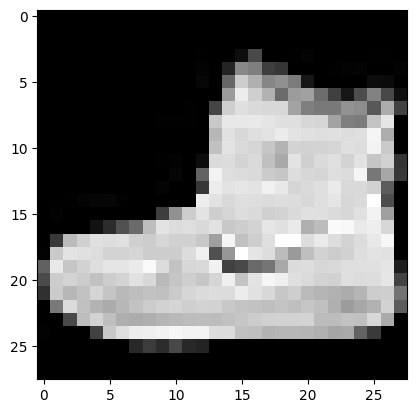

In [69]:
plt.imshow(X_train[0],cmap="gray")

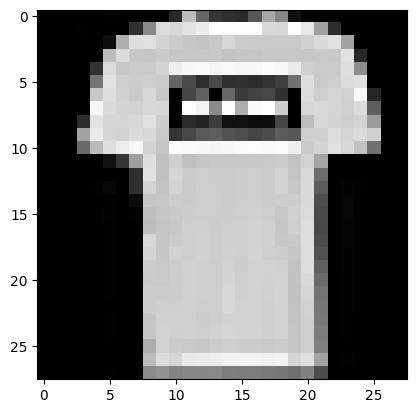

In [70]:
plt.imshow(X_train[1],cmap="gray")


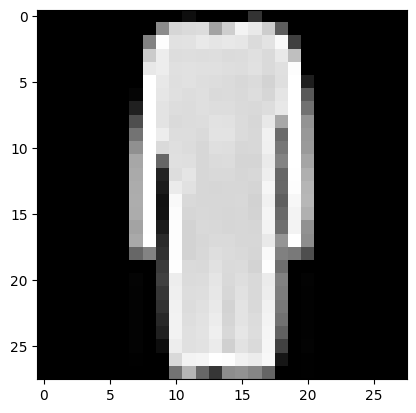

In [71]:
plt.imshow(X_train[25],cmap="gray")


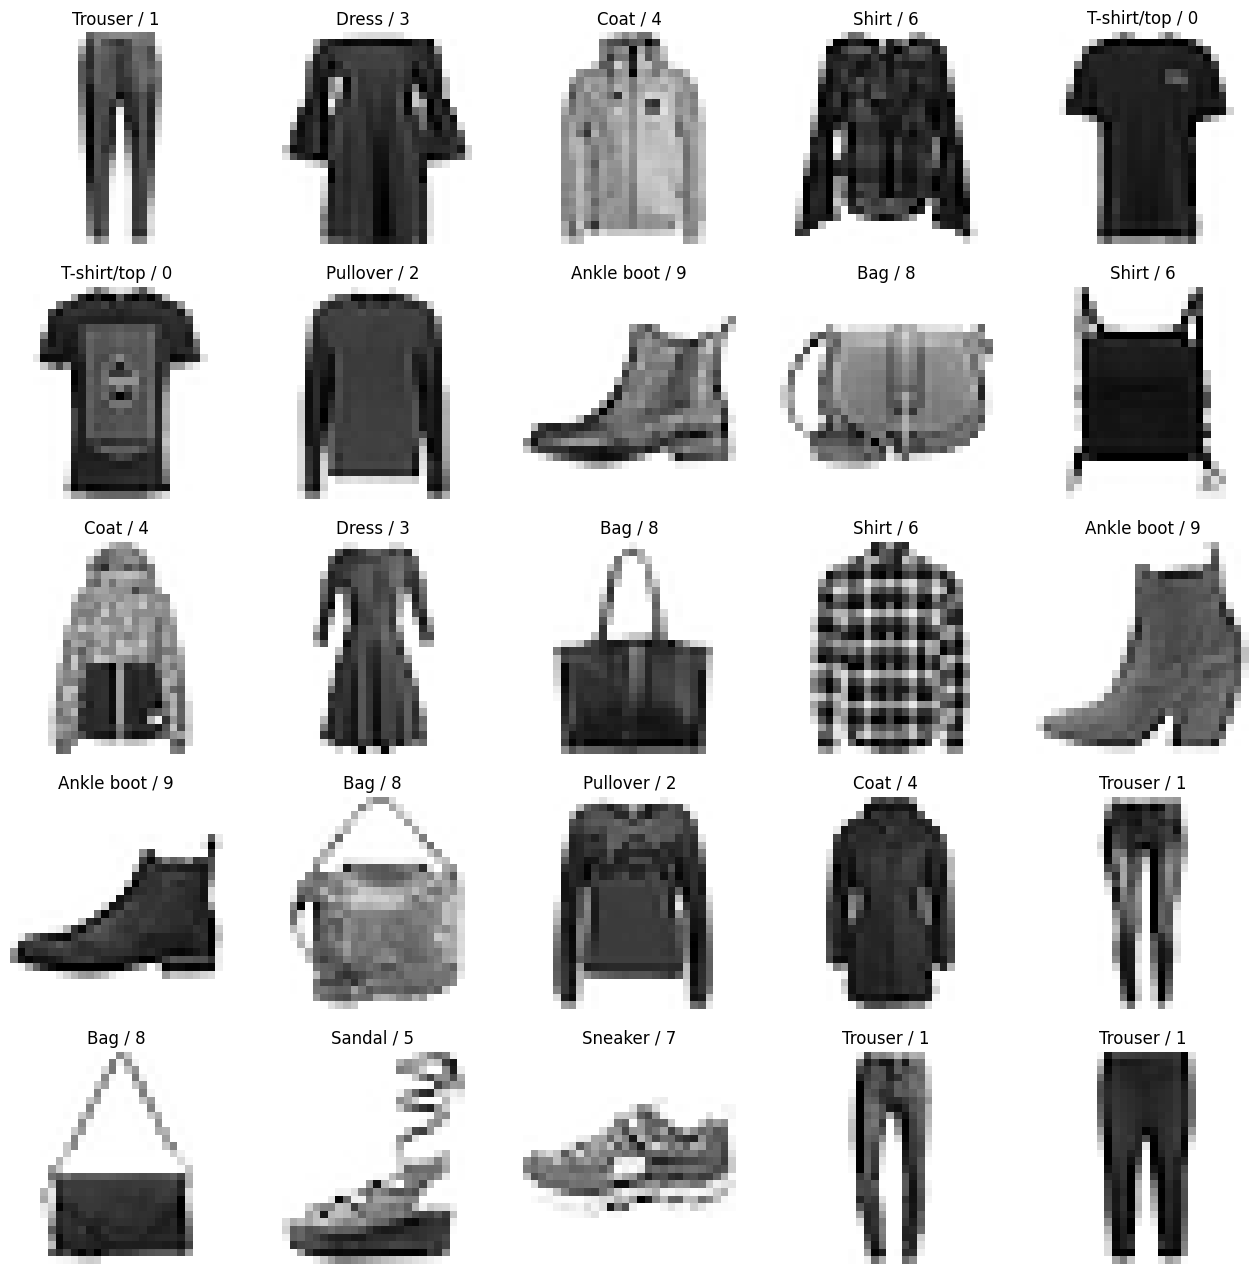

In [72]:
plt.figure(figsize=(16,16))
j = 1
for i in np.random.randint(0,1000,25):
    plt.subplot(5,5,j); j +=1
    plt.imshow(X_train[i],cmap = 'Greys')
    plt.axis('off')
    plt.title('{} / {}'.format(class_labels[y_train[i]],y_train[i]))
    

In [73]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train,y_train),(X_test,y_test) = fashion_mnist.load_data()
X_train = np.expand_dims(X_train,axis=-1)
X_test = np.expand_dims(X_test,axis=-1)
ei1 = np.array(pd.unique(y_train))
eindex1 = []
print(ei1)

for i in ei1:
    eindex1.append(list(y_train).index(i))
print(eindex1)

[9 0 3 2 7 5 1 6 4 8]
[0, 1, 3, 5, 6, 8, 16, 18, 19, 23]


(28, 28, 1)
(28, 28, 1)
(28, 28, 1)
(28, 28, 1)
(28, 28, 1)
(28, 28, 1)
(28, 28, 1)
(28, 28, 1)
(28, 28, 1)
(28, 28, 1)


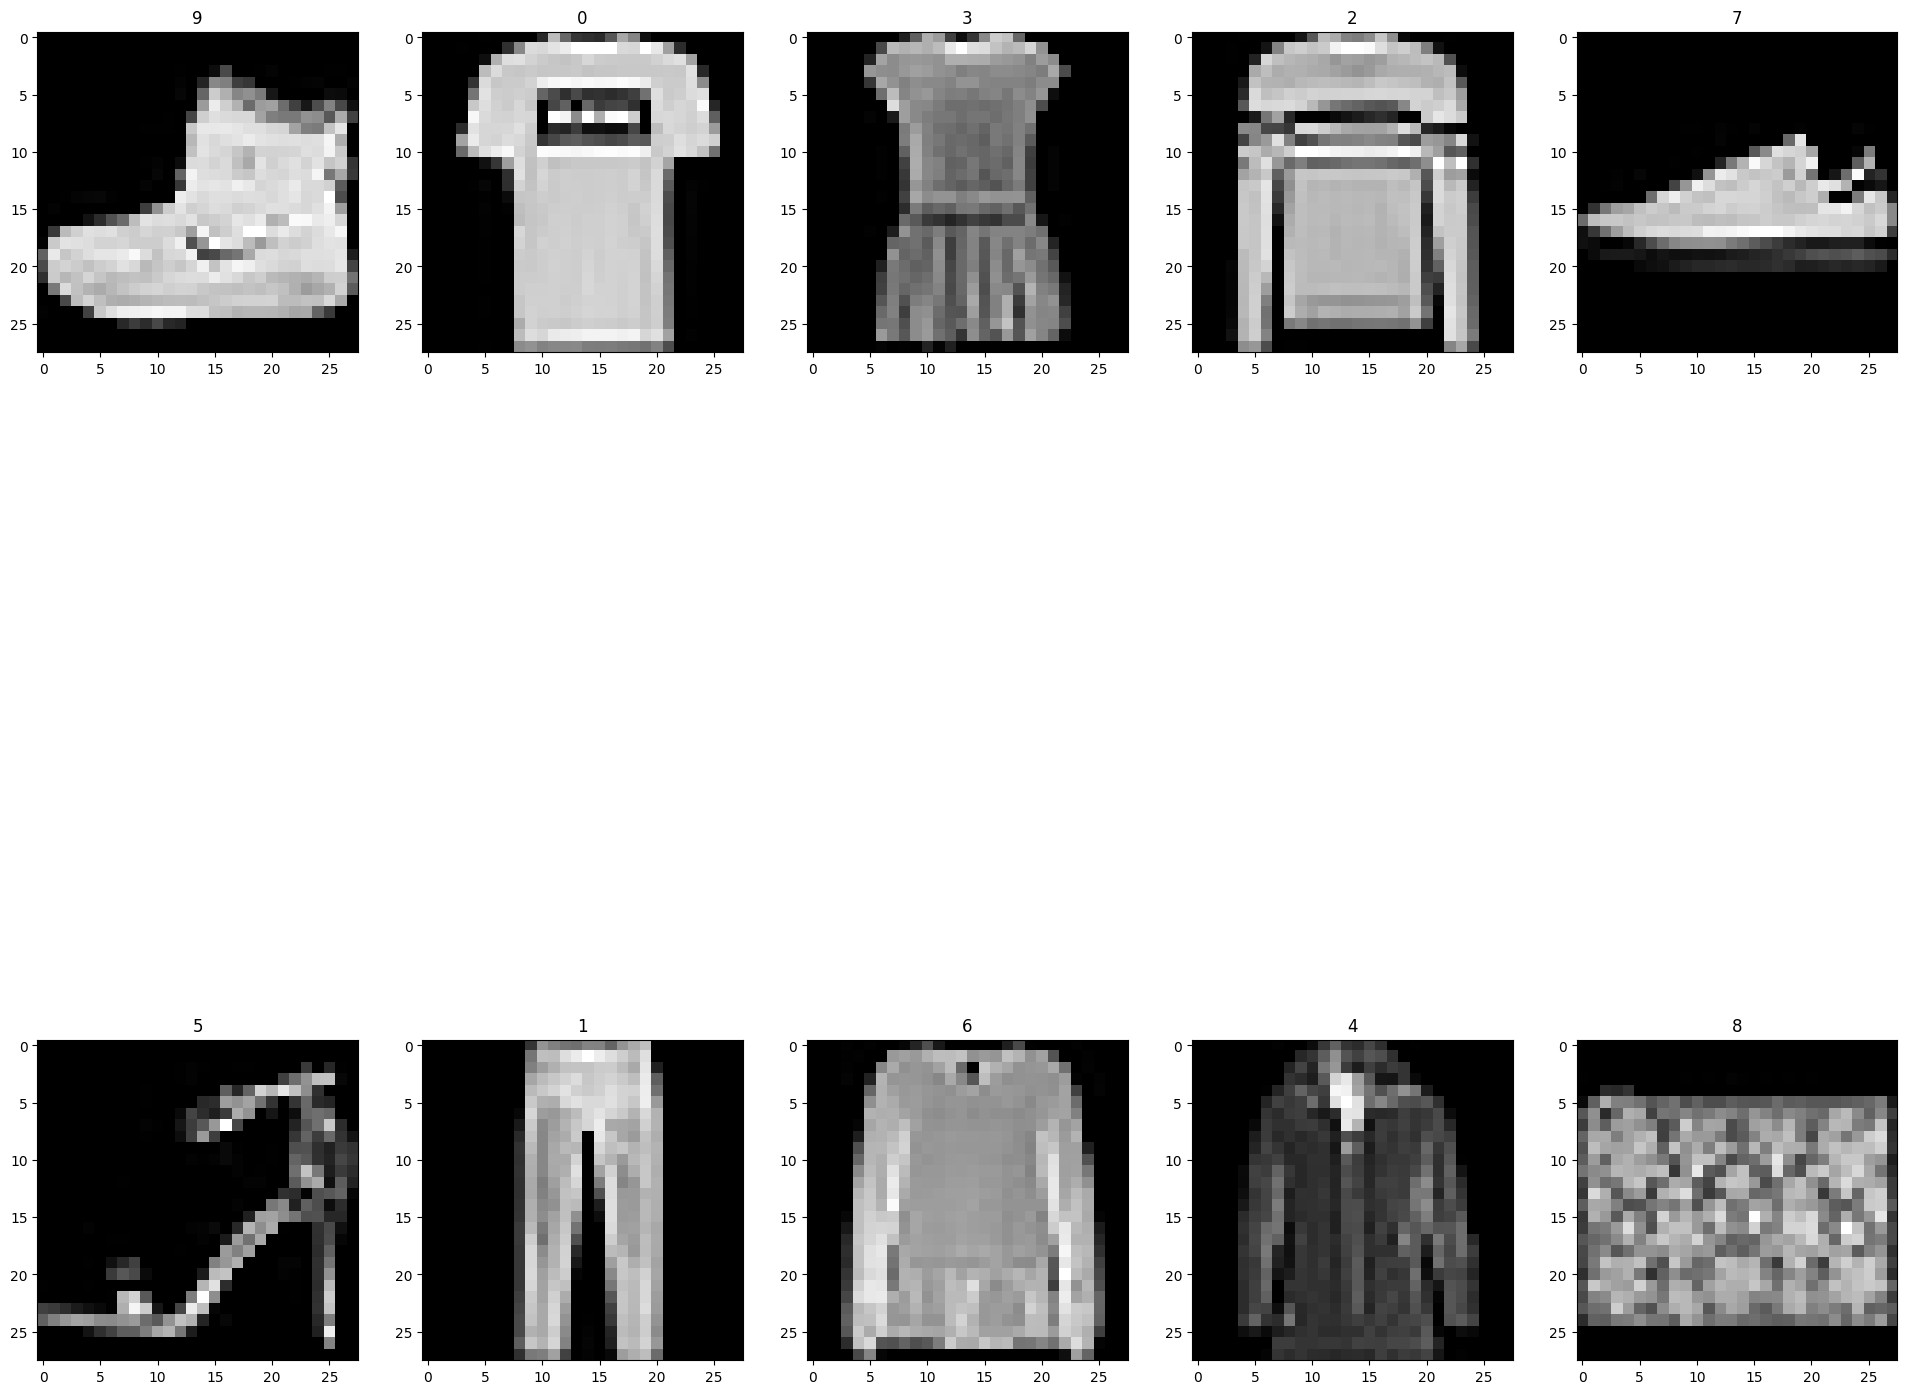

In [74]:
plt.figure(figsize= (24,24))

for x,y in enumerate(eindex1):
    print(X_train[y].shape)
    plt.subplot(2,5,x+1)
    plt.imshow(tensorflow.squeeze(X_train[y]),cmap = 'gray')
    plt.title('{}'.format(ei1[x]))

In [75]:
X_train.shape

(60000, 28, 28, 1)

In [76]:
X_train = X_train/255.0
X_test = X_test/255.0

In [78]:
from sklearn.model_selection import train_test_split

In [79]:
X_train,X_val,y_train,y_val=train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [80]:
X_train.shape,y_train.shape

((48000, 28, 28, 1), (48000,))

In [81]:
X_val.shape,y_val.shape

((12000, 28, 28, 1), (12000,))

In [ ]:
model = keras.models.Sequential([ 
    keras.layers.Conv2D(64, (3, 3), strides =(1,1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(128, (3, 3), strides =(1,1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), strides =(1,1)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.10),
    keras.layers.Dense(10, activation='softmax')
])

In [ ]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])


In [107]:
model.fit(X_train,y_train,epochs = 20,batch_size=500,validation_data=(X_val,y_val),verbose=1)

Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 316ms/step - accuracy: 0.9780 - loss: 0.0636 - val_accuracy: 0.9038 - val_loss: 0.5256
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 267ms/step - accuracy: 0.9791 - loss: 0.0609 - val_accuracy: 0.9017 - val_loss: 0.5116
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 275ms/step - accuracy: 0.9798 - loss: 0.0591 - val_accuracy: 0.9022 - val_loss: 0.4844
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 265ms/step - accuracy: 0.9807 - loss: 0.0577 - val_accuracy: 0.9027 - val_loss: 0.4888
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 270ms/step - accuracy: 0.9809 - loss: 0.0564 - val_accuracy: 0.9006 - val_loss: 0.4596
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 264ms/step - accuracy: 0.9831 - loss: 0.0483 - val_accuracy: 0.9006 - val_loss: 0.4913
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 268ms/step - accuracy: 0.9822 - loss: 0.0495 - val_accuracy: 0.9014 - val_loss: 0.4980
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 266ms/step - accuracy: 0.9819 - loss: 0.0529 - val_accu

In [108]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [109]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8984 - loss: 0.6390


[0.6390478014945984, 0.8984000086784363]

In [112]:
from sklearn.metrics import accuracy_score,classification_report


In [113]:
print(accuracy_score(y_test,y_pred.argmax(axis=1)))

0.8984


In [114]:
print(classification_report(y_test,y_pred.argmax(axis=1)))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1000
           1       1.00      0.97      0.99      1000
           2       0.82      0.85      0.83      1000
           3       0.89      0.92      0.90      1000
           4       0.85      0.83      0.84      1000
           5       0.96      0.98      0.97      1000
           6       0.74      0.70      0.72      1000
           7       0.95      0.95      0.95      1000
           8       0.97      0.97      0.97      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

